In [1]:
from sklearn.datasets import make_circles
n_samples = 1000

X,y= make_circles(n_samples=n_samples, noise=0.05, random_state=42)

In [2]:
import pandas as pd
circles=pd.DataFrame({"X0":X[:,0],"X1":X[:,1],"label":y})
circles.head()

,X0,X1,label
0,0.742207,0.246686,1
1,-0.734032,0.168692,1
2,-0.829859,0.221959,1
3,-0.429136,0.672230,1
4,0.445602,-0.894936,0


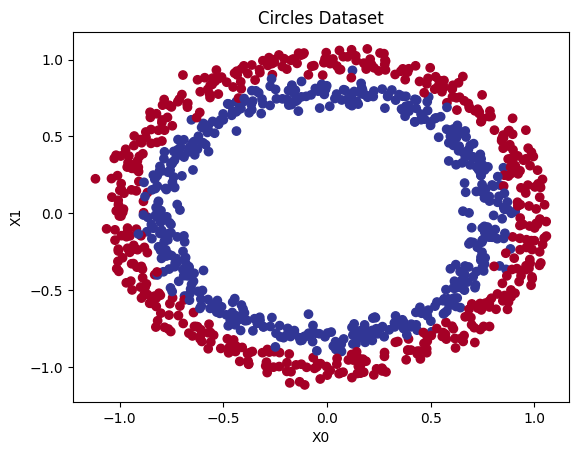

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("X0")
plt.ylabel("X1")
plt.title("Circles Dataset")
plt.show()

In [4]:
# plotting decision boundary
import numpy as np
import matplotlib.pyplot as plt
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
# plotting scatter plot and also decision boundary
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(device)
    
    model.eval()
    with torch.inference_mode():
        Z = model(grid).squeeze()
        Z = torch.round(torch.sigmoid(Z)).cpu().numpy()
    
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.title('Decision Boundary')
    plt.show()

In [5]:
# check input and output shapes
print(f"Input shape: {X.shape}")
print(f"Output shape: {y.shape}")


Input shape: (1000, 2)
Output shape: (1000,)


In [6]:
# Turning the data into tensors and creating train and test splits
import torch

X_tensor = torch.from_numpy(X).float()
y_tensor = torch.from_numpy(y).type(torch.int)

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

In [8]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [9]:
# building model
import torch
from torch import nn
# 1. set up the device
device = "cuda" if torch.cuda.is_available() else "cpu"
device
# 2. construct the model (by subclassing nn.Module)
class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        
    def forward(self, x):
        return self.layer_3(self.layer_2(self.layer_1(x)))
# 3. instantiate the model and send it to the target device
model_0 = CircleModel().to(device)
model_0
# 4. define loss fuction and optimizer
# loss_fn = nn.BCELoss()   # input has to be passed through a sigmoid activation function before calculating the loss
loss_fn = nn.BCEWithLogitsLoss()   # it has a sigmoid activation function built in
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
# 5. create training and testing loop
EPOCHS = 300
for epoch in range(EPOCHS):
    model_0.train()
    y_logits = model_0(X_train.to(device)).squeeze()  # output of the model before activation function
    y_pred = torch.round(torch.sigmoid(y_logits))  # output of the model after activation function
    # loss=loss_fn(torch.sigmoid(y_logits), y_train.to(device).float())  # if using BCELoss, pass the output through sigmoid activation function before calculating the loss
    loss = loss_fn(y_logits, y_train.to(device).float())
    acc = (y_pred == y_train.to(device)).float().mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

Epoch: 0 | Loss: 0.6992 | Accuracy: 0.5000
Epoch: 50 | Loss: 0.6958 | Accuracy: 0.5000
Epoch: 100 | Loss: 0.6944 | Accuracy: 0.5000
Epoch: 150 | Loss: 0.6937 | Accuracy: 0.5000
Epoch: 200 | Loss: 0.6935 | Accuracy: 0.5738
Epoch: 250 | Loss: 0.6933 | Accuracy: 0.5250


In [10]:
with torch.inference_mode():
    y_logits = model_0(X_test.to(device)).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    acc = (y_pred == y_test.to(device)).float().mean()
    print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.5550


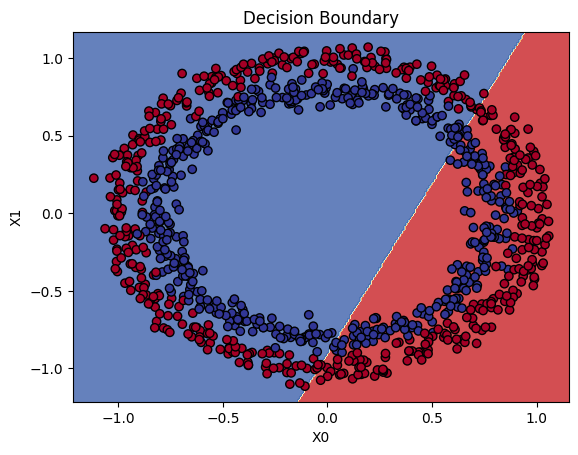

In [11]:
plot_decision_boundary(model_0, X_tensor.cpu().numpy(), y_tensor.cpu().numpy())

In [12]:
# we can create model using nn.Sequential as well
model_1 = nn.Sequential(
    nn.Linear(in_features=2, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=10),
    nn.ReLU(),
    nn.Linear(in_features=10, out_features=1)
).to(device)
model_1

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)

In [13]:
#  imporving model from model prespective
# 1. add more layers
# 2. add more hidden units
# 3. change the activation function
# 4. change the optimization function
# 5. fit for more epochs
# 6. change the learning rate
# these all are hyperparameters which can be tuned to improve the model performance

In [14]:
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)
        
    def forward(self, x):
        x=self.layer_1(x)
        x=self.layer_2(x)
        x=self.layer_3(x)
        return x
    
# loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()   # it has a sigmoid activation function built in
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.01)

torch.manual_seed
torch.cuda.manual_seed(42)
epochs = 1000
X_train,X_test=X_train.to(device),X_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)
model_2=CircleModelV2().to(device)
for epoch in range(epochs):
    model_2.train()
    y_logits = model_2(X_train).squeeze()  # output of the model before activation function
    y_pred = torch.round(torch.sigmoid(y_logits))  # output of the model after activation function
    loss = loss_fn(y_logits, y_train.float())
    acc = (y_pred == y_train).float().mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

Epoch: 0 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 50 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 100 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 150 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 200 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 250 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 300 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 350 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 400 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 450 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 500 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 550 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 600 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 650 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 700 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 750 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 800 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 850 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 900 | Loss: 0.7028 | Accuracy: 0.5000
Epoch: 950 | Loss: 0.7028 | Accuracy: 0.5000


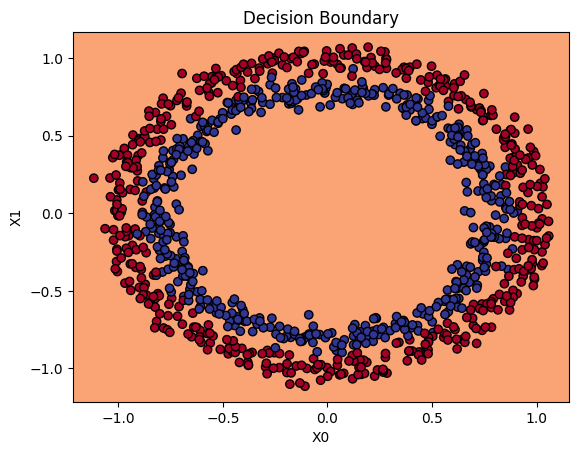

In [15]:
plot_decision_boundary(model_2, X_tensor.cpu().numpy(), y_tensor.cpu().numpy())

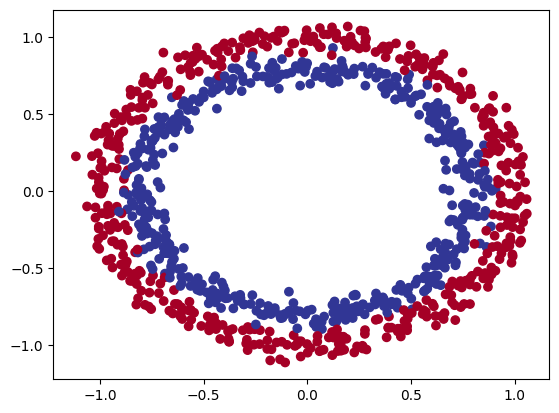

In [16]:
from sklearn.datasets import make_circles
n_samples=1000
X,y= make_circles(n_samples=n_samples, noise=0.05, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [17]:
# conveting the data into tensors and then split
from sklearn.model_selection import train_test_split
import torch
from torch import nn
X=torch.from_numpy(X).float()
y=torch.from_numpy(y).int()

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
class CircleModelV3(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=20)
        self.layer_2 = nn.Linear(in_features=20, out_features=20)
        self.layer_3 = nn.Linear(in_features=20, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))


model_3=CircleModelV3().to(device)
# loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(params=model_3.parameters(),lr=0.1)

# training loop
EPOCHS=1000
for epoch in range(EPOCHS):
    model_3.train()
    y_logits=model_3(X_train.to(device)).squeeze()
    y_pred=torch.round(torch.sigmoid(y_logits))
    loss=loss_fn(y_logits,y_train.to(device).float())
    acc=(y_pred==y_train.to(device)).float().mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # testing
    model_3.eval()
    with torch.inference_mode():
        y_logits_test=model_3(X_test.to(device)).squeeze()
        y_pred_test=torch.round(torch.sigmoid(y_logits_test))
        acc_test=(y_pred_test==y_test.to(device)).float().mean()
    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.4f} | Test Accuracy: {acc_test:.4f}")

Epoch: 0 | Loss: 0.6945 | Accuracy: 0.5150 | Test Accuracy: 0.5000
Epoch: 50 | Loss: 0.0577 | Accuracy: 0.9850 | Test Accuracy: 0.9300
Epoch: 100 | Loss: 0.0350 | Accuracy: 0.9925 | Test Accuracy: 0.9250
Epoch: 150 | Loss: 0.2121 | Accuracy: 0.9262 | Test Accuracy: 0.8750
Epoch: 200 | Loss: 0.0359 | Accuracy: 0.9875 | Test Accuracy: 0.9400
Epoch: 250 | Loss: 0.0311 | Accuracy: 0.9875 | Test Accuracy: 0.9450
Epoch: 300 | Loss: 0.0293 | Accuracy: 0.9875 | Test Accuracy: 0.9400
Epoch: 350 | Loss: 0.0276 | Accuracy: 0.9900 | Test Accuracy: 0.9400
Epoch: 400 | Loss: 0.0268 | Accuracy: 0.9900 | Test Accuracy: 0.9400
Epoch: 450 | Loss: 0.0263 | Accuracy: 0.9912 | Test Accuracy: 0.9400
Epoch: 500 | Loss: 0.0258 | Accuracy: 0.9912 | Test Accuracy: 0.9400
Epoch: 550 | Loss: 0.0256 | Accuracy: 0.9912 | Test Accuracy: 0.9400
Epoch: 600 | Loss: 0.0252 | Accuracy: 0.9912 | Test Accuracy: 0.9350
Epoch: 650 | Loss: 0.0250 | Accuracy: 0.9912 | Test Accuracy: 0.9300
Epoch: 700 | Loss: 0.0247 | Accuracy:

In [19]:
# testing
model_3.eval()
with torch.inference_mode():
    y_logits_test=model_3(X_test.to(device)).squeeze()
    y_pred_test=torch.round(torch.sigmoid(y_logits_test))
    acc_test=(y_pred_test==y_test.to(device)).float().mean()
print(f"Final Test Accuracy: {acc_test:.4f}")

Final Test Accuracy: 0.9250


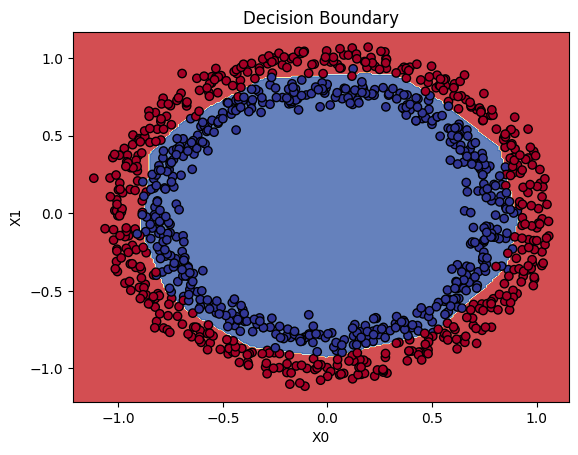

In [20]:

plot_decision_boundary(model_3, X.cpu().numpy(), y.cpu().numpy())

## Multiclass Classification

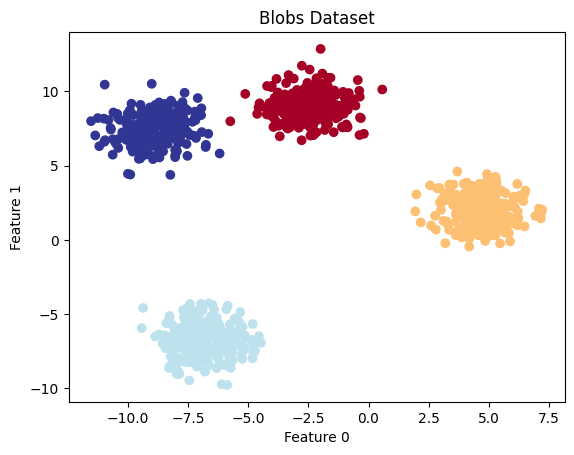

In [21]:
# creating toy dataset
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs   #creating multiple clusters of data
from sklearn.model_selection import train_test_split
NUM_CLASSES=4
NUM_FEATURES=2
RANDOM_SEED=42

# 1. create the data
X,y=make_blobs(n_samples=1000, centers=NUM_CLASSES, n_features=NUM_FEATURES, random_state=RANDOM_SEED)
# turing the data into tensors and then split
X=torch.from_numpy(X).float()
y=torch.from_numpy(y).long()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=RANDOM_SEED)

# visualizing
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Blobs Dataset")
plt.show()

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [23]:
class BlobModel(nn.Module):
    '''
    A simple neural network for blob classification
    '''
    # def __init__(self, input_features, output_features,hidden_units=8):
    #     super().__init__()
    #     self.layer_1 = nn.Linear(in_features=input_features, out_features=hidden_units)
    #     self.layer_2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
    #     self.layer_3 = nn.Linear(in_features=hidden_units, out_features=output_features)
    #     self.relu = nn.ReLU()
    def __init__(self, input_features, output_features,hidden_units=8):
        super().__init__()
        self.layer=nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
        
    def forward(self, x):
        return self.layer(x)

model_4=BlobModel(input_features=NUM_FEATURES, output_features=NUM_CLASSES).to(device)
model_4

BlobModel(
  (layer): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [24]:
# loss function and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_4.parameters(), lr=0.01)

# training loop
EPOCHS=400
X_train,X_test=X_train.to(device),X_test.to(device)
y_train,y_test=y_train.to(device),y_test.to(device)
for epoch in range(EPOCHS):
    model_4.train()
    y_logits=model_4(X_train.to(device))
    loss=loss_fn(y_logits, y_train.to(device))
    y_pred=torch.softmax(y_logits, dim=1)
    acc=(y_pred.argmax(dim=1)==y_train.to(device)).float().mean()
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # testing
    with torch.inference_mode():
        y_logits_test=model_4(X_test.to(device)).squeeze()
        y_pred_test=torch.softmax(y_logits_test, dim=1)
        acc_test=(y_pred_test.argmax(dim=1)==y_test.to(device)).float().mean()
        
    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Training Loss: {loss:.4f} | Train Accuracy: {acc:.4f} | Test Accuracy: {acc_test:.4f}")

Epoch: 0 | Training Loss: 1.8148 | Train Accuracy: 0.2612 | Test Accuracy: 0.2050
Epoch: 50 | Training Loss: 0.9038 | Train Accuracy: 0.6988 | Test Accuracy: 0.6600
Epoch: 100 | Training Loss: 0.5426 | Train Accuracy: 0.9837 | Test Accuracy: 0.9850
Epoch: 150 | Training Loss: 0.2807 | Train Accuracy: 0.9975 | Test Accuracy: 0.9950
Epoch: 200 | Training Loss: 0.1491 | Train Accuracy: 0.9975 | Test Accuracy: 0.9950
Epoch: 250 | Training Loss: 0.0913 | Train Accuracy: 0.9987 | Test Accuracy: 1.0000
Epoch: 300 | Training Loss: 0.0629 | Train Accuracy: 0.9987 | Test Accuracy: 1.0000
Epoch: 350 | Training Loss: 0.0469 | Train Accuracy: 0.9987 | Test Accuracy: 1.0000


In [26]:
# making and evalutaing predictsion with pytorch mutliclass model
model_4.eval()
with torch.inference_mode():
    y_logits_test=model_4(X_test.to(device)).squeeze()
    y_pred_test=torch.softmax(y_logits_test, dim=1)
    y_pred_test_classes=y_pred_test.argmax(dim=1)
    acc_test=(y_pred_test_classes==y_test.to(device)).float().mean()
print(f"Final Test Accuracy: {acc_test:.4f}")


Final Test Accuracy: 1.0000


In [29]:
def _plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(device)
    
    model.eval()
    with torch.inference_mode():
        Z = model(grid)
        Z = torch.softmax(Z, dim=1).argmax(dim=1).cpu().numpy()
    
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.cpu(), edgecolors='k', cmap=plt.cm.RdYlBu)
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.title('Decision Boundary')
    plt.show()

/tmp/ipykernel_18051/3489821964.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))


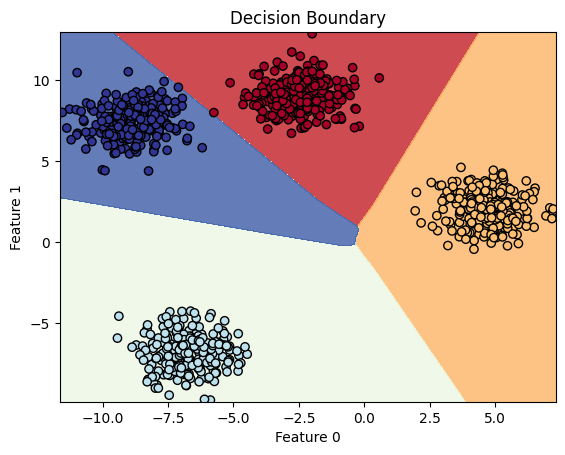

In [30]:
_plot_decision_boundary(model_4, X, y)

In [31]:
# a few classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,classification_report

y_test_pred = model_4(X_test.to(device)).argmax(dim=1)
print(f"Test Accuracy: {accuracy_score(y_test.cpu(), y_test_pred.cpu()):.4f}")
print(f"Test Precision: {precision_score(y_test.cpu(), y_test_pred.cpu(), average='macro'):.4f}")
print(f"Test Recall: {recall_score(y_test.cpu(), y_test_pred.cpu(), average='macro'):.4f}")
print(f"Test F1-Score: {f1_score(y_test.cpu(), y_test_pred.cpu(), average='macro'):.4f}")

Test Accuracy: 1.0000
Test Precision: 1.0000
Test Recall: 1.0000
Test F1-Score: 1.0000


In [33]:
print(classification_report(y_test.cpu(), y_test_pred.cpu()))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        49
           1       1.00      1.00      1.00        41
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        57

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [35]:
print(confusion_matrix(y_test.cpu(), y_test_pred.cpu()))

[[49  0  0  0]
 [ 0 41  0  0]
 [ 0  0 53  0]
 [ 0  0  0 57]]


In [ ]:
# when to use accuracy -> default metric for classification problems, works well when classes are balanced. but don't use when classes are imbalanced, in that case use precision, recall and f1-score.

# when to use precision, recall and f1-score -> when classes are imbalanced, in that case accuracy can be misleading, in that case use precision, recall and f1-score. precision is the ratio of true positives to the sum of true positives and false positives. recall is the ratio of true positives to the sum of true positives and false negatives. f1-score is the harmonic mean of precision and recall. 

In [ ]:
# accuracy -> torchmetrics.Accuracy() or sklearn.metrics.accuracy_score() -> use when it is balanced

# precision -> torchmetrics.Precision() or sklearn.metrics.precision_score() -> use when it is imbalanced, it is the ratio of true positives to the sum of true positives and false positives. Higher precision leads to less false positives.

# recall -> torchmetrics.Recall() or sklearn.metrics.recall_score() -> use when it is imbalanced, it is the ratio of true positives to the sum of true positives and false negatives. Higher recall leads to less false negatives.

# F1-score -> torchmetrics.F1Score() or sklearn.metrics.f1_score() -> use when it is imbalanced, it is the harmonic mean of precision and recall. Higher F1-score leads to better balance between precision and recall.

# thereis always tradeoff between precision and recall, increasing one will decrease the other, so it is important to choose the right metric based on the problem at hand.

In [37]:
# !pip install torchmetrics

In [41]:
from torchmetrics import Accuracy
torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)
acc = torchmetrics_accuracy(y_pred_test_classes, y_test.to(device))
print(f"Test Accuracy using torchmetrics: {acc:.4f}")

Test Accuracy using torchmetrics: 1.0000
